In [3]:
# import libraries
import numpy as np
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh
import networkx as nx
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.linalg import cho_factor, cho_solve

from tqdm import tqdm

In [31]:
from functions import *

In [9]:
# Load
edges, n_vertices, edge_weights = load_graph("./baseball (1).mtx")

✓ Loaded: ./baseball (1).mtx
  Vertices : 30
  Edges    : 300
  Weighted : yes



In [11]:
# Phase 1
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built and verified
  Matrix size : 30 x 30
  Degree range: [162, 162]



In [13]:
# Phase 2
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min)

✓ lambda_min = 0.246914
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  Smallest eigenvalue of L_sigma: 10.000000



In [15]:
# Phase 3
np.random.seed(42)
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.0128, 0.0150]



In [17]:
# Phase 4
k = compute_permeability(u, edges, edge_weights)

✓ Phase 4 complete: permeabilities computed
  min k_e : 2.9752
  max k_e : 19.1869
  mean k_e: 8.1001



In [19]:
# Gamma in/out
degrees_arr = A.sum(axis=1)
gamma_in    = list(np.argsort(degrees_arr)[-5:])
gamma_out   = list(np.argsort(degrees_arr)[:5])

In [21]:
# Phase 5 & 6
L_k = build_weighted_laplacian(edges, n_vertices, k)
p   = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)
Q   = extract_qoi(p, k, edges, gamma_out)
print(f"Single sample Q = {Q:.6f}")

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

Single sample Q = -439.253790


In [36]:
def monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None, N=1000):
    """
    Monte Carlo loop with tqdm progress bar.
    Runs Phases 3-6 N times and records Q each step.
    """
    B         = build_incidence_matrix(edges, n_vertices)
    cho_cache = cho_factor(L_sigma)
    Q_samples = np.zeros(N)

    with tqdm(total=N, desc="Monte Carlo", unit="sample") as pbar:
        for i in range(N):
            # Phase 3
            w = np.random.randn(len(edges))
            f = B @ w
            u = cho_solve(cho_cache, lambda_min * f)

            # Phase 4
            k = {(vi, vj): np.exp((u[vi] + u[vj]) / 2) *
                 (edge_weights.get((vi,vj), edge_weights.get((vj,vi), 1.0))
                  if edge_weights else 1.0)
                 for (vi, vj) in edges}

            # Phase 5
            L_k = build_weighted_laplacian(edges, n_vertices, k)
            p   = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

            # Phase 6
            Q_samples[i] = extract_qoi(p, k, edges, gamma_out)

            pbar.update(1)
            pbar.set_postfix({"mean Q": f"{Q_samples[:i+1].mean():.4f}"})

    print(f"\n✓ Done — {N} samples complete")
    print(f"  Mean Q : {Q_samples.mean():.6f}")
    print(f"  Std Q  : {Q_samples.std():.6f}")
    print(f"  Var Q  : {Q_samples.var():.6f}")

    return Q_samples


In [39]:
# Phase 7
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                   gamma_in, gamma_out, edge_weights=None, N=100)

Monte Carlo:  25%|██▌       | 25/100 [00:00<00:00, 125.35sample/s, mean Q=-52.7341]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0

Monte Carlo:  58%|█████▊    | 58/100 [00:00<00:00, 152.14sample/s, mean Q=-52.7263]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0

Monte Carlo:  91%|█████████ | 91/100 [00:00<00:00, 166.00sample/s, mean Q=-52.7254]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0

Monte Carlo: 100%|██████████| 100/100 [00:00<00:00, 160.59sample/s, mean Q=-52.7231]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]

✓ Phase 5 complete: pressure field solved
  pressure range: [0.0000, 1.0000]


✓ Done — 100 samples complete
  Mean Q : -52.723067
  Std Q  : 0.046375
  Var Q  : 0.002151



=== Monte Carlo Results ===
  Samples : 100
  Mean Q  : -52.723067
  Std Q   : 0.046375
  Var Q   : 0.002151
  Min Q   : -52.817493
  Max Q   : -52.587405


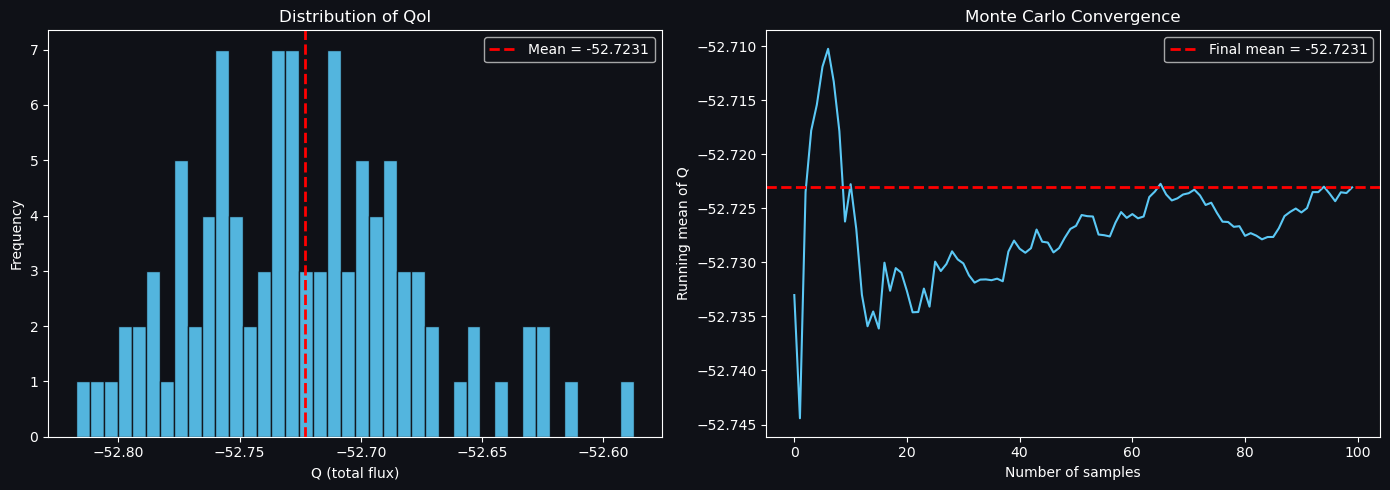

In [41]:
analyze_qoi(Q_samples)